In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tools.eda import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [52]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [53]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# EDA

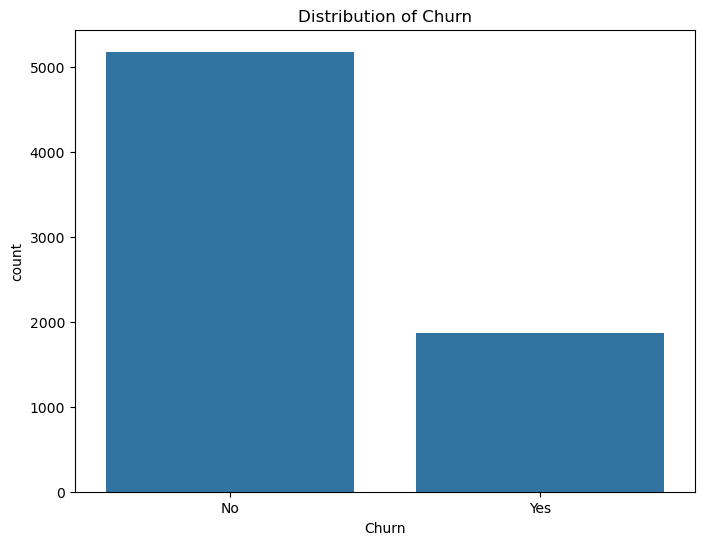

In [55]:

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.show()

In [56]:
def get_numerical_and_categorical_features(
    df: pd.DataFrame,
    ignore_columns: list = None
) -> tuple[list, list]:
    """
    Identify numerical and categorical features in a DataFrame.

    Args:
        df: Pandas DataFrame to analyze.
        ignore_columns: List of column names to exclude from the analysis.

    Returns:
        tuple: (numerical_features, categorical_features)
    """
    if ignore_columns is None:
        ignore_columns = []
    
    # Get all numerical and categorical features
    num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()
    
    # Filter out ignored columns
    num_features = [col for col in num_features if col not in ignore_columns]
    cat_features = [col for col in cat_features if col not in ignore_columns]
    
    return num_features, cat_features

In [57]:
TARGET = "Churn"
num_features, cat_features = get_numerical_and_categorical_features(
    df,
    ignore_columns=["customerID", "Churn"]
)

/var/folders/4t/35nfm0b159g9bz03rt5zzm_h0000gn/T/ipykernel_19284/2352443174.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()


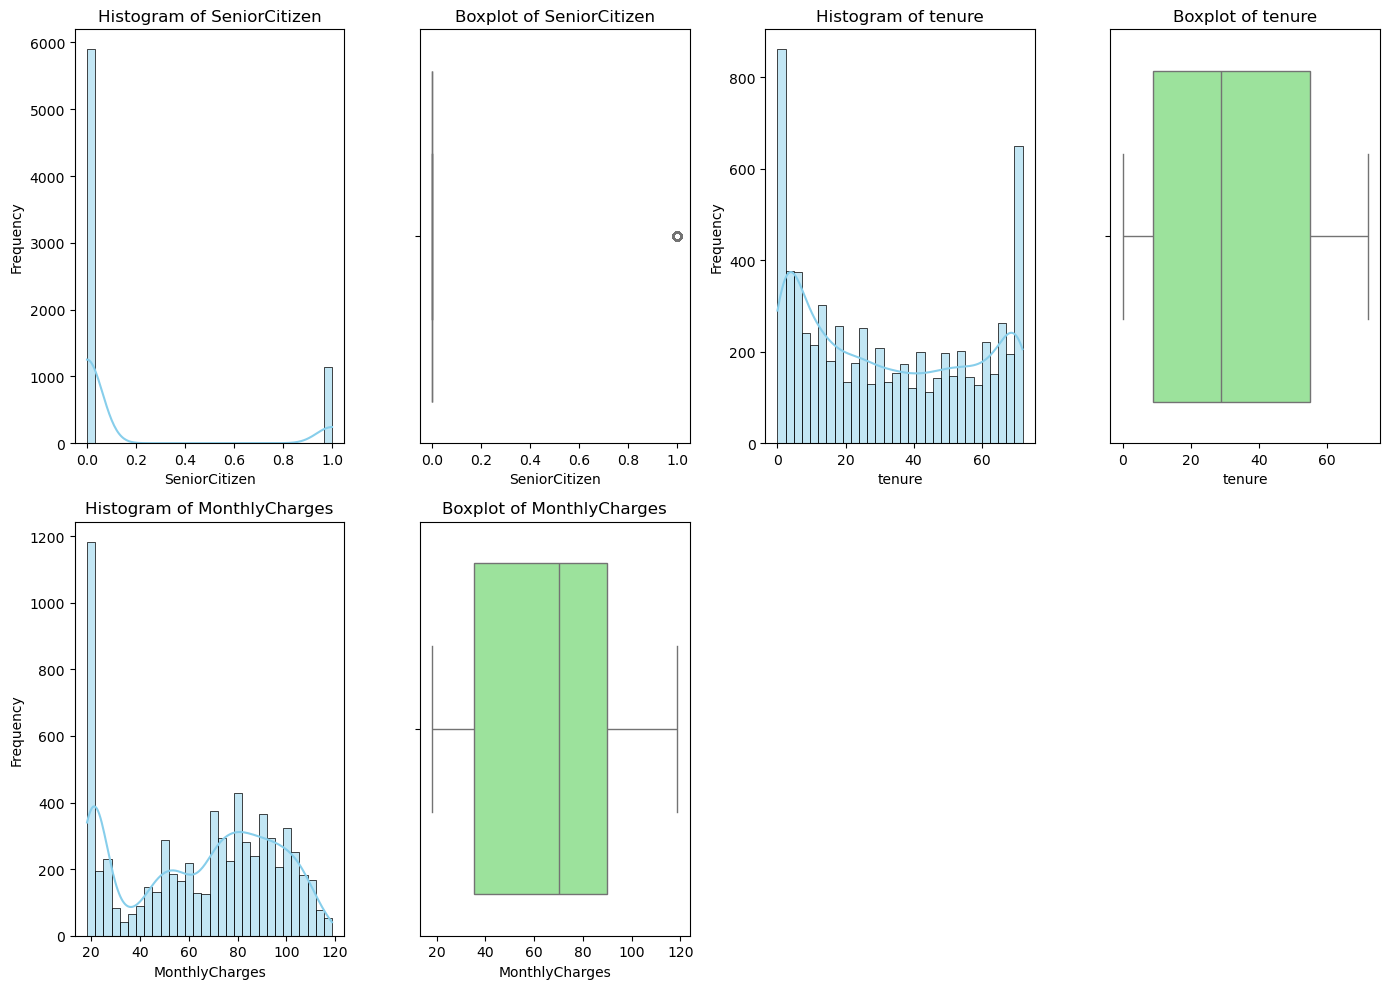

In [58]:
plot_numerical_distributions(df, num_features, bins=30)

In [59]:
summary = compute_numerical_summary(df, num_features, cardinality_threshold=10)
print(summary)


Statistics for SeniorCitizen:
Missing Values: 0 (0.00%)
Skewness: 1.83
Kurtosis: 1.36
Unique values: 2
⚠️  Feature 'SeniorCitizen' might be categorical (unique < 10)

Percentiles:
  5%:  0.00
  25%: 0.00
  50%: 0.00
  75%: 0.00
  95%: 1.00

Statistics for tenure:
Missing Values: 0 (0.00%)
Skewness: 0.24
Kurtosis: -1.39
Unique values: 73

Percentiles:
  5%:  1.00
  25%: 9.00
  50%: 29.00
  75%: 55.00
  95%: 72.00

Statistics for MonthlyCharges:
Missing Values: 0 (0.00%)
Skewness: -0.22
Kurtosis: -1.26
Unique values: 1585

Percentiles:
  5%:  19.65
  25%: 35.50
  50%: 70.35
  75%: 89.85
  95%: 107.40
          feature  missing_count  missing_pct  unique_values  skewness  \
0   SeniorCitizen              0          0.0              2  1.833633   
1          tenure              0          0.0             73  0.239540   
2  MonthlyCharges              0          0.0           1585 -0.220524   

   kurtosis       mean        std    min     max  
0  1.362596   0.162147   0.368612   0.00    1

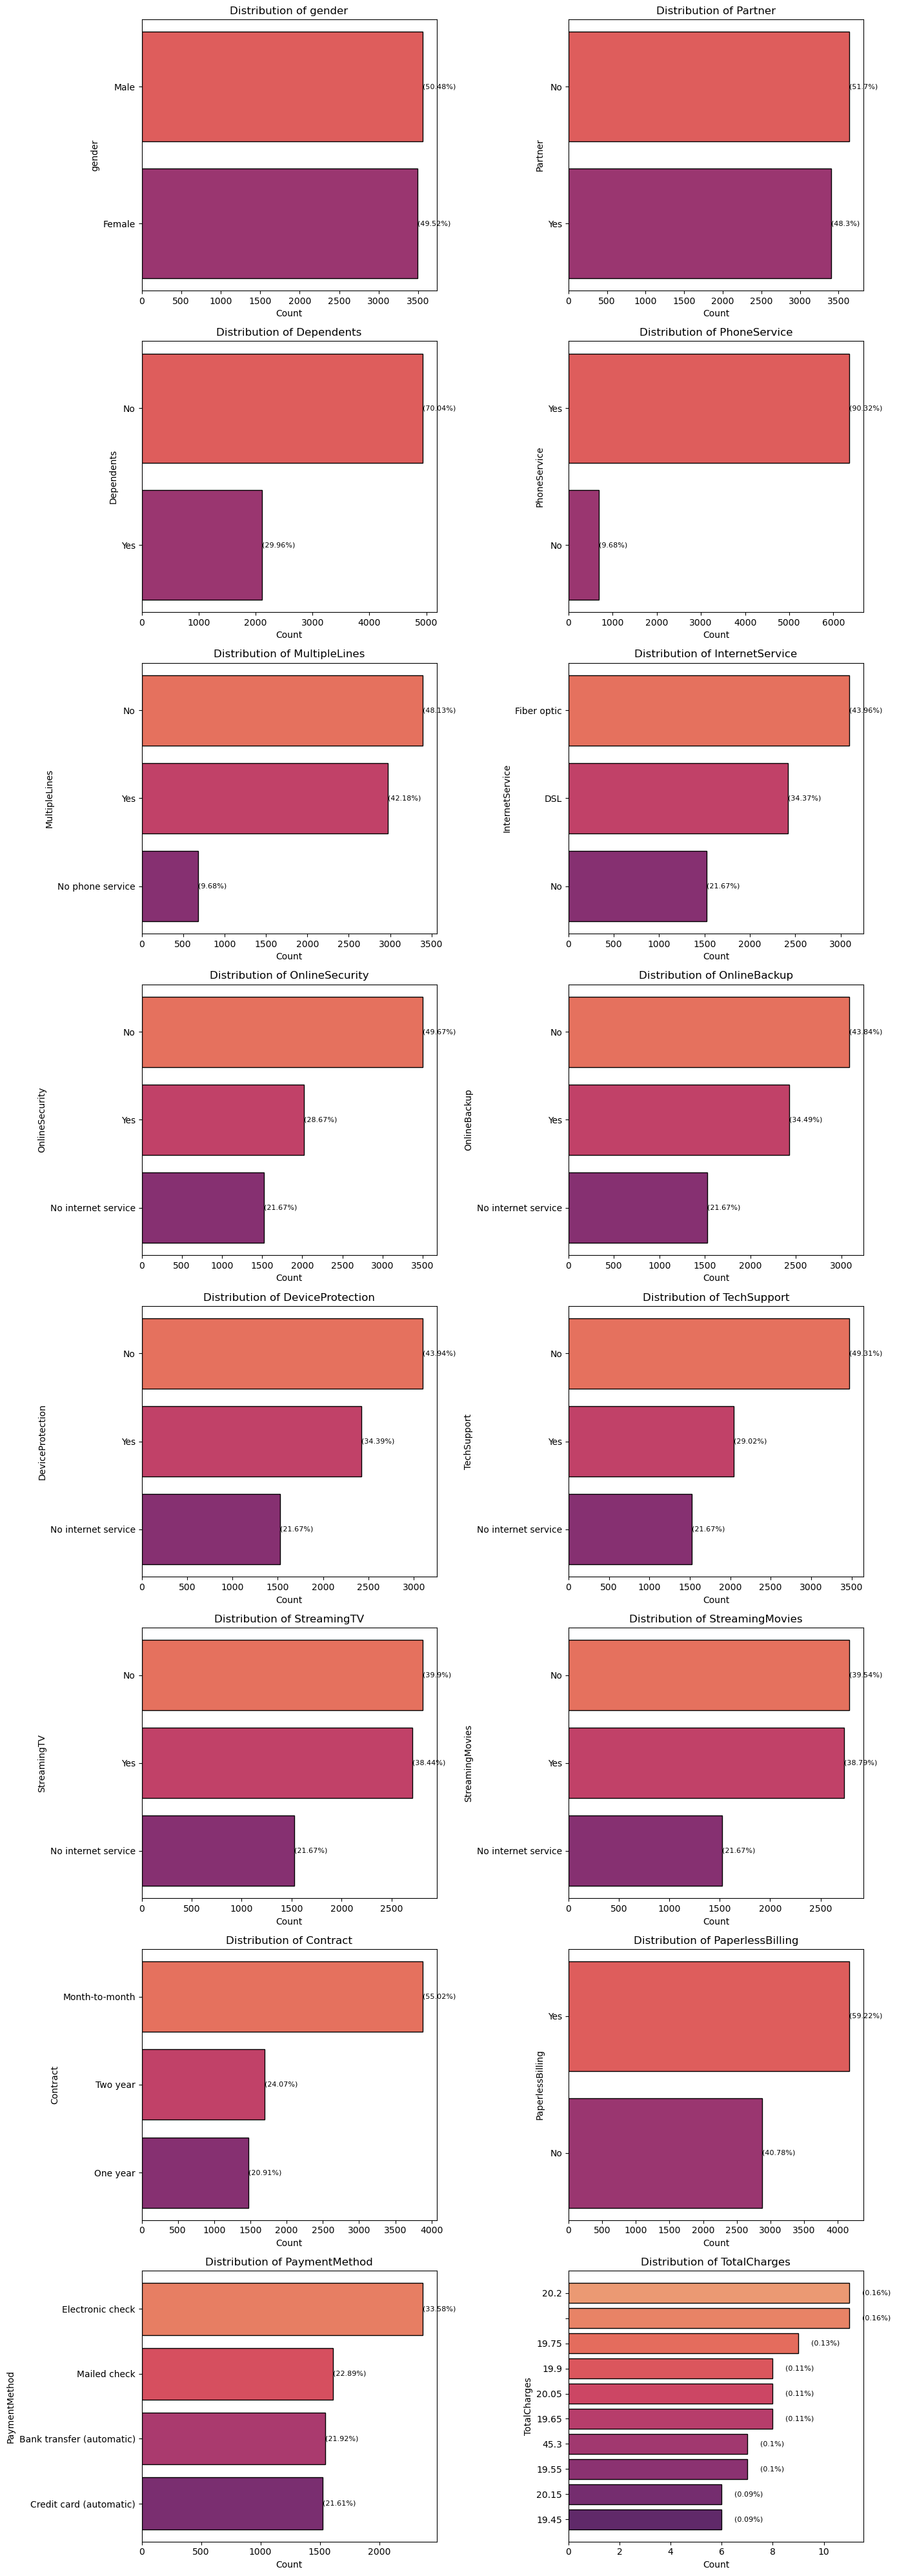

In [60]:
plot_categorical_distributions(df, cat_features)

In [61]:
summary = compute_categorical_summary(df, cat_features, cardinality_threshold=10)
print(summary)


Statistics for gender:
Missing Values: 0 (0.00%)
Unique values: 2
Mode: Male (count: 3555)
ℹ️  Binary feature detected

Top 10 value counts:
  Male: 3555 (50.48%)
  Female: 3488 (49.52%)

Statistics for Partner:
Missing Values: 0 (0.00%)
Unique values: 2
Mode: No (count: 3641)
ℹ️  Binary feature detected

Top 10 value counts:
  No: 3641 (51.70%)
  Yes: 3402 (48.30%)

Statistics for Dependents:
Missing Values: 0 (0.00%)
Unique values: 2
Mode: No (count: 4933)
ℹ️  Binary feature detected

Top 10 value counts:
  No: 4933 (70.04%)
  Yes: 2110 (29.96%)

Statistics for PhoneService:
Missing Values: 0 (0.00%)
Unique values: 2
Mode: Yes (count: 6361)
ℹ️  Binary feature detected

Top 10 value counts:
  Yes: 6361 (90.32%)
  No: 682 (9.68%)

Statistics for MultipleLines:
Missing Values: 0 (0.00%)
Unique values: 3
Mode: No (count: 3390)

Top 10 value counts:
  No: 3390 (48.13%)
  Yes: 2971 (42.18%)
  No phone service: 682 (9.68%)

Statistics for InternetService:
Missing Values: 0 (0.00%)
Unique v

/Users/lilianabadillo/Projects/repo/ml-projects/tools/eda.py:296: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=categorical_column, y=feature, palette='viridis', ax=ax)
/Users/lilianabadillo/Projects/repo/ml-projects/tools/eda.py:296: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=categorical_column, y=feature, palette='viridis', ax=ax)
/Users/lilianabadillo/Projects/repo/ml-projects/tools/eda.py:296: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=categorical_column, y=feature, palette='viridis', ax=ax)


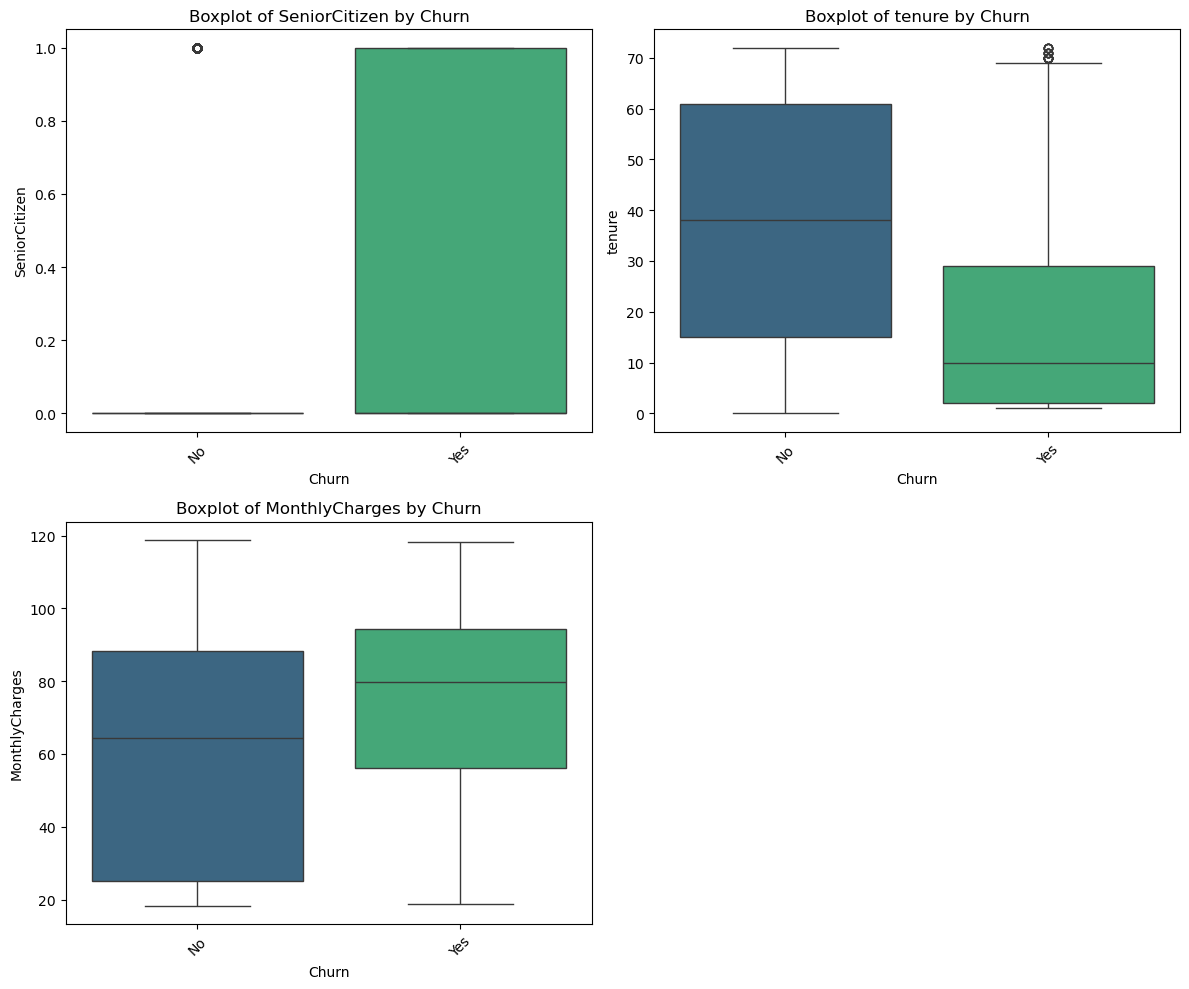

In [62]:
plot_numerical_distribution_by_category(df, num_features, categorical_column=TARGET)

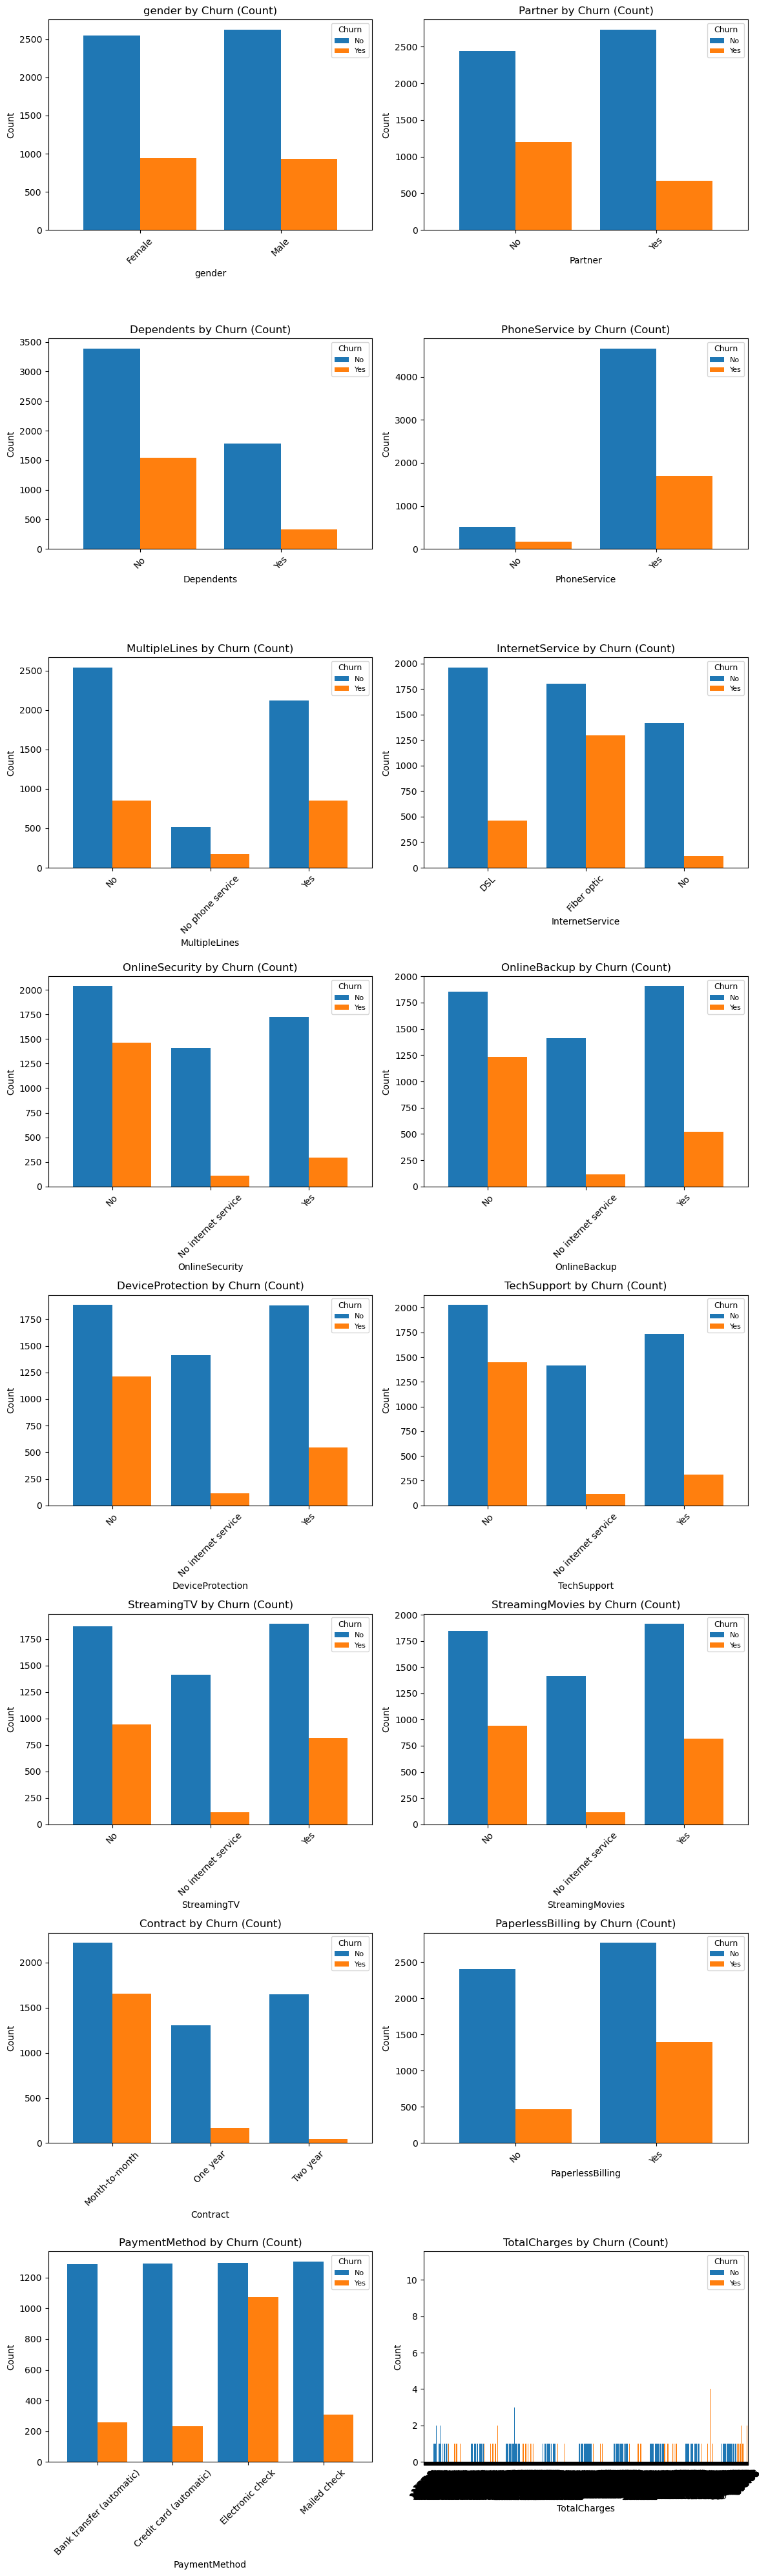

In [63]:
plot_categorical_distribution_by_category(df, cat_features, groupby_column=TARGET)

In [64]:
df['TotalCharges'].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64

## Data cleaning

In [65]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0.0).astype(float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [66]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [67]:
df['gender'] = df['gender'].astype('category')
df['Partner'] = df['Partner'].astype('category')
df['Dependents'] = df['Dependents'].astype('category')
df['PhoneService'] = df['PhoneService'].astype('category')
df['MultipleLines'] = df['MultipleLines'].astype('category')
df['InternetService'] = df['InternetService'].astype('category')
df['OnlineSecurity'] = df['OnlineSecurity'].astype('category')
df['OnlineBackup'] = df['OnlineBackup'].astype('category')
df['DeviceProtection'] = df['DeviceProtection'].astype('category')
df['TechSupport'] = df['TechSupport'].astype('category')
df['StreamingTV'] = df['StreamingTV'].astype('category')
df['StreamingMovies'] = df['StreamingMovies'].astype('category')
df['Contract'] = df['Contract'].astype('category')
df['PaperlessBilling'] = df['PaperlessBilling'].astype('category')
df['PaymentMethod'] = df['PaymentMethod'].astype('category')

In [68]:
# Re-identify features after type conversion
num_features, cat_features = get_numerical_and_categorical_features(
    df,
    ignore_columns=["customerID", "Churn"]
)

/var/folders/4t/35nfm0b159g9bz03rt5zzm_h0000gn/T/ipykernel_19284/2352443174.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()


## Split data

In [69]:
X = df[cat_features + num_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic regression (baseline model)

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
    
model_pipeline.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [71]:
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

